In [1]:
# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [3]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 128
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}


(-0.2, 10.2)

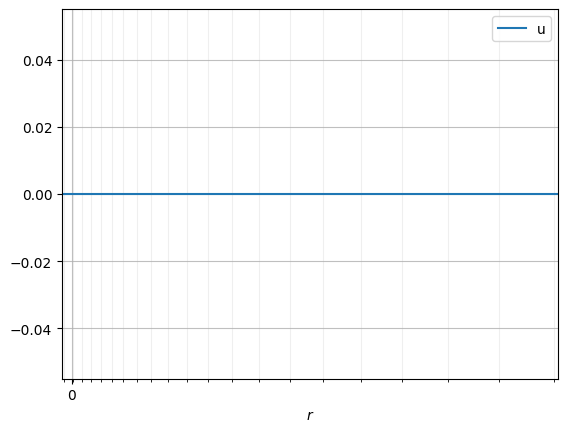

In [4]:
initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

#plot initial conditions
plt.xlabel('r')
plt.plot(r, initial_u, label='u')
#plt.plot(r, initial_v, label='v')
#plt.plot(r, initial_arr, label='arr')
#plt.plot(r, initial_att, label='att')
#plt.plot(r, initial_K, label='K')
#plt.plot(r, initial_phi, label='phi')
#plt.plot(r, initial_hrr, '.', label='hrr') # zero, but plot as dots to see the grid
#plt.plot(r, initial_lapse, label='lapse')
#plt.plot(r, initial_lambdar, label='lambdar')
plt.legend(loc='best')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,10.2)
#plt.ylim(-0.001,0.001)

In [5]:
# check the Hamiltonian and momentum constraints are initially satisfied
#Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)

# plot the profile for Ham
#plt.plot(r, Ham[0])
#plt.plot(r, Mom[0])

#plt.xlabel('r')
#plt.ylabel('Ham value')
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)
#plt.xlim(-0.5,R+2)
#plt.ylim(-0.1,0.1)

In [6]:
# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

'''# check the Hamiltonian and momentum constraints are initially satisfied
Ham_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)

# plot the profiles for Ham
plt.plot(r, Ham[0],'--',label="LR Ham")
plt.plot(r_HR, Ham_HR[0],'-',label="HR Ham")
plt.plot(r_HR, Ham_HR[0] * 2.0**4.0,':',label="LR Ham predicted by 4th order convergence")

plt.xlabel('r')
plt.ylabel('Ham value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0.0,2)
plt.ylim(-0.0001,0.0001)
plt.legend();'''

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


'# check the Hamiltonian and momentum constraints are initially satisfied\nHam_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter)\n\n# plot the profiles for Ham\nplt.plot(r, Ham[0],\'--\',label="LR Ham")\nplt.plot(r_HR, Ham_HR[0],\'-\',label="HR Ham")\nplt.plot(r_HR, Ham_HR[0] * 2.0**4.0,\':\',label="LR Ham predicted by 4th order convergence")\n\nplt.xlabel(\'r\')\nplt.ylabel(\'Ham value\')\nax = plt.gcf().gca()\nset_grid_on_ax(ax, r)\nplt.xlim(0.0,2)\nplt.ylim(-0.0001,0.0001)\nplt.legend();'

horizon is at r = 0.5


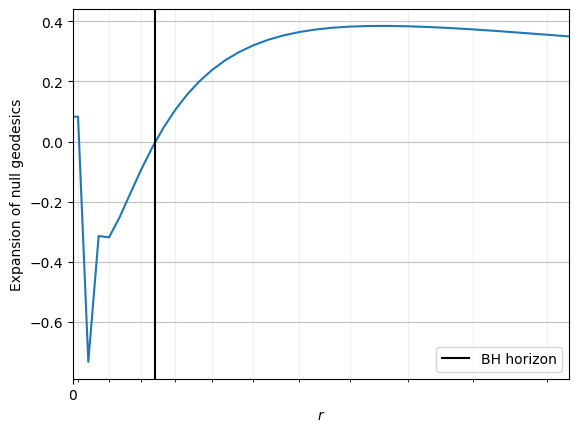

In [17]:
# find the apparent horizon for a given set of states
omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)

# plot the null expansion omega and its zero crossing
plt.plot(r, omega[0])
plt.axvline(x=ah_radius[0],c="k",label="BH horizon")
plt.xlabel('r')
plt.ylabel('Expansion of null geodesics')
plt.legend(loc="best")
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0,3)
#plt.ylim(-0.1,0.1)

print("horizon is at r =", round(ah_radius[0],1))

In [8]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 10
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 250

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

# Evolution of scalar field 

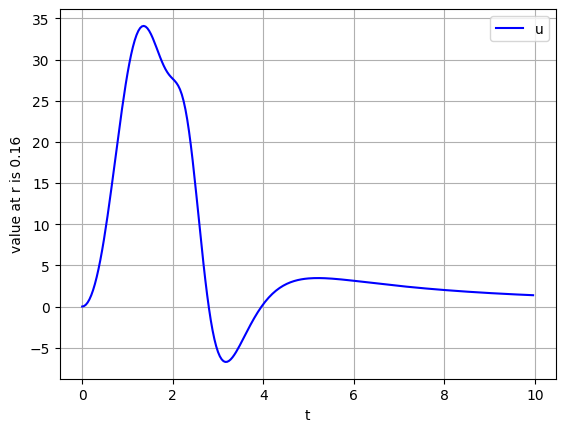

In [9]:
# Plot a single point versus time
idx_u = 12

var1 = idx_u

idx = NUM_GHOSTS + 2 # Choose an inner point

r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

# Evolution of the Scalar Field at AH

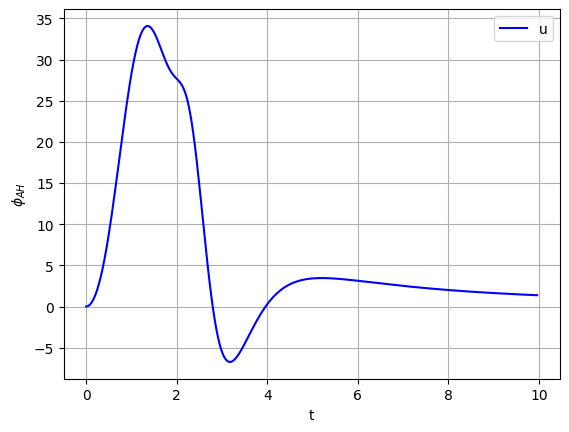

In [22]:
# Plot a single point versus time
idx_u = 12
var1 = idx_u

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)

# var1: you multiply by this value to have the correct offset in your long 1D array (which is the thing your solution outputs after the simulation)
# num_point : the amount of points on your grid, dependant on the resolution you use.
# idx : Selects the specific spatial point with r_i, you can also check to which 'radius' this grid point corresponds to.

var1_of_t = solution[:, var1 * num_points + idx]

plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('$\phi_{AH}$')
plt.legend(loc='best')
plt.grid()

# Evolution of lapse

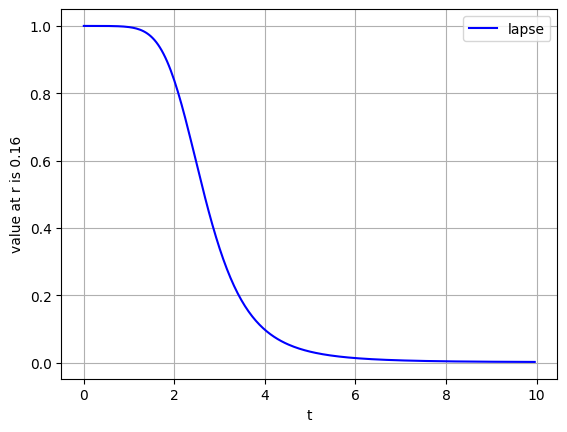

In [15]:
# Plot a single point versus time
idx_u = 12

var1 = idx_lapse

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

## Extrinsic Curvature

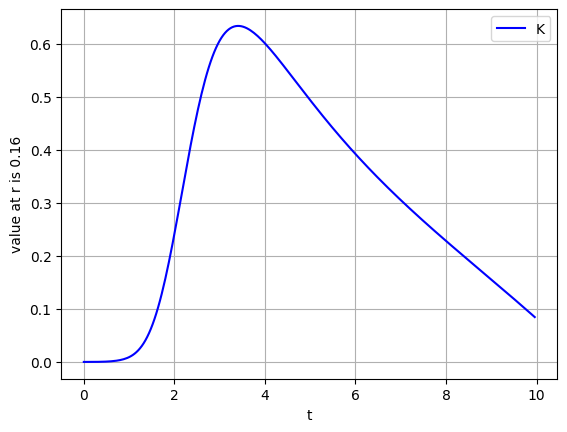

In [16]:
# Plot a single point versus time
idx_u = 12

var1 = idx_K

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

## Different variables at different radii and different times

(-10.0, 10.0)

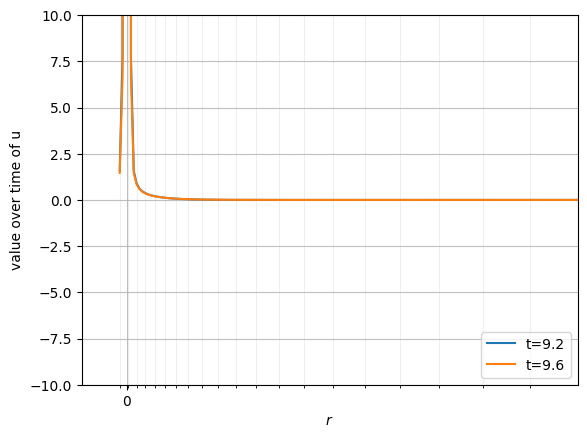

In [14]:
# plot the profile for some variable at a selection of times
#var = idx_lapse # I suggest looking at shiftr, lapse, K or phi to see the gauge evolution
#var = idx_K
var = 12
for i, t_i in enumerate(t) :
    if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-1,10)
plt.ylim(-10,10)

In [18]:
# calculate the diagnostics, just the Hamiltonian constraint for now
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)

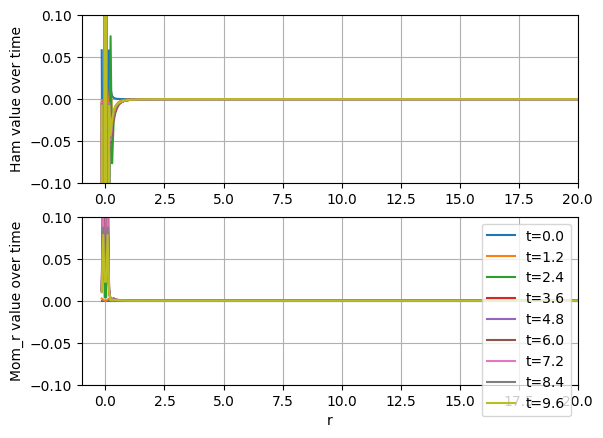

In [19]:
# plot the profile for Ham and Mom at a selection of times

for i, t_i in enumerate(t) :
    if (i < num_points_t) and (i % 30 == 0) :
        labelt = "t="+str(round(t_i,2))
        Ham_t = Ham[i,:]
        ax1 = plt.subplot(211)
        plt.plot(r, Ham_t, label=labelt)
        ax2 = plt.subplot(212)
        Mom_t = np.sqrt(Mom[i,:,i_r]**2 + Mom[i,:,i_t]**2 + Mom[i,:,i_p]**2)
        plt.plot(r, Mom_t, label=labelt)

plt.legend()
ax2.set_xlabel('r')
ax1.set_ylabel('Ham value over time')
ax1.set_xlim(-1,20.0)
ax1.set_ylim(-0.1,0.1)
ax1.grid()
ax2.set_ylabel('Mom_r value over time')
ax2.set_xlim(-1,20.0)
ax2.set_ylim(-0.1,0.1)
ax2.grid()

t:  [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8  2.84 2.88 2.92 2.96 3.   3.04 3.08 3.12 3.16 3.2  3.24 3.28 3.32
 3.36 3.4  3.44 3.48 3.52 3.56 3.6  3.64 3.68 3.72 3.76 3.8  3.84 3.88
 3.92 3.96 4.   4.04 4.08 4.12 4.16 4.2  4.24 4.28 4.32 4.36 4.4  4.44
 4.48 4.52 4.56 4.6  4.64 4.68 4.72 4.76 4.8  4.84 4.88 4.92 4.96 5.
 5.04 5.08 5.12 5.16 5.2  5.24 5.28 5.32 5.36 5.4  5.44 5.48 5.52 5.56
 5.6  5.64 5.68 5.72 5.76 5.8  5.84 5.88 5.92 5.96 6.   6.04 6.08 6.12
 6.16 6.2  6.24 6.28 6.32 6.36 6.4  6.44 6.48 6.52 6.56 6.6  6.64 6.68
 6.72 6.76 6.8  6.84 6.88 6.92 6.96 7.   7.04 7.08 7.12 7.16 7.2  7.24
 7.28 7.32 7.36 7.4  7.44 7.48 7.52 7.56 7.6  7.64 7.68 7.72 7.76 7.8
 7.84 

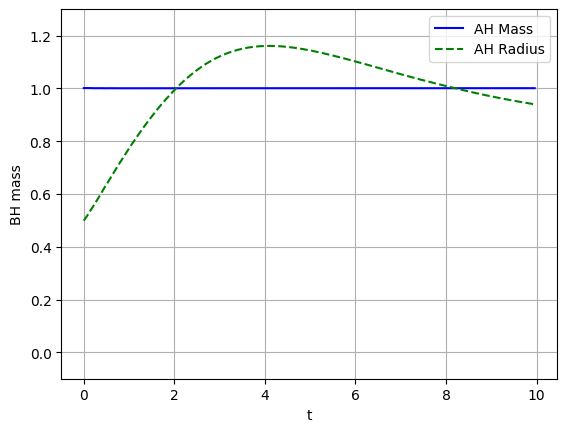

In [20]:
# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

plt.plot(t, bh_mass, 'b-', label="AH Mass")
plt.plot(t, ah_radius, 'g--', label="AH Radius")
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('BH mass')
plt.legend(loc='best')
plt.ylim(-0.1,1.3)
print('t: ', t)
print('R_{AH}: ', ah_radius)

plt.grid()